In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('shipment.csv')

# Clean the data by removing single tick symbols from the beginning of the cells
df = df.map(lambda x: x.lstrip("'") if isinstance(x, str) else x)

# Convert cargo columns to numeric after cleaning
df['import_cargo'] = pd.to_numeric(df['import_cargo'], errors='coerce')
df['export_cargo'] = pd.to_numeric(df['export_cargo'], errors='coerce')

# Drop rows where cargo values are NaN after conversion, if any
df.dropna(subset=['import_cargo', 'export_cargo'], inplace=True)

      portname  import_cargo
54219   Manila        595251
53777   Manila        530262
51437   Manila        494892


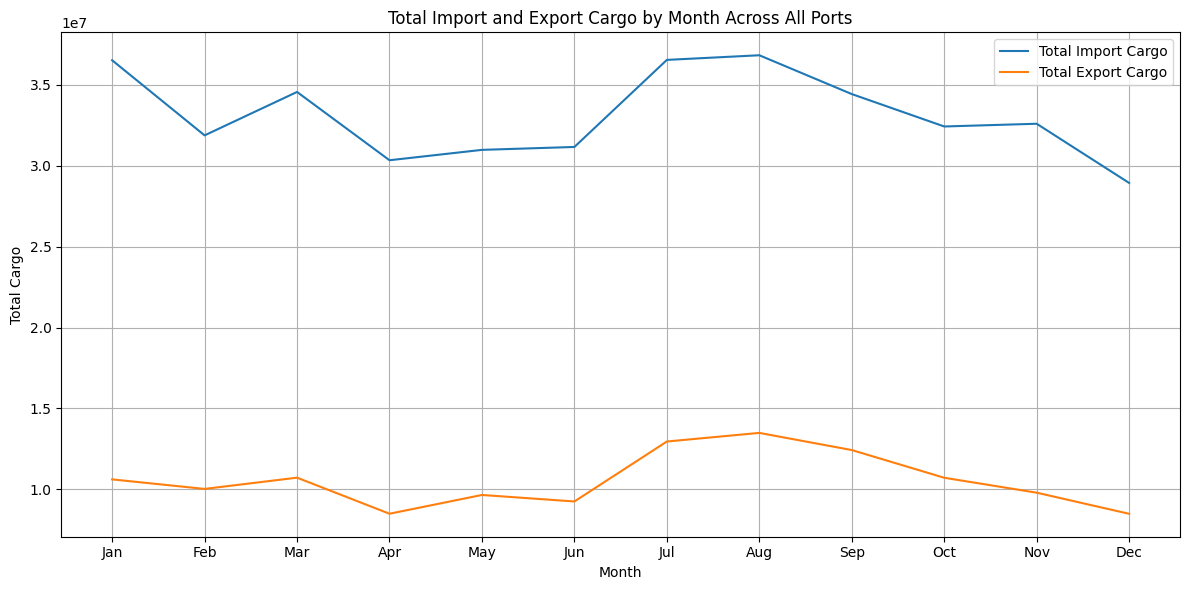

In [35]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

monthly_traffic = df.groupby('month')[['import_cargo', 'export_cargo']].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(monthly_traffic['month'], monthly_traffic['import_cargo'], label='Total Import Cargo')
plt.plot(monthly_traffic['month'], monthly_traffic['export_cargo'], label='Total Export Cargo')
plt.title('Total Import and Export Cargo by Month Across All Ports')
plt.xlabel('Month')
plt.ylabel('Total Cargo')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

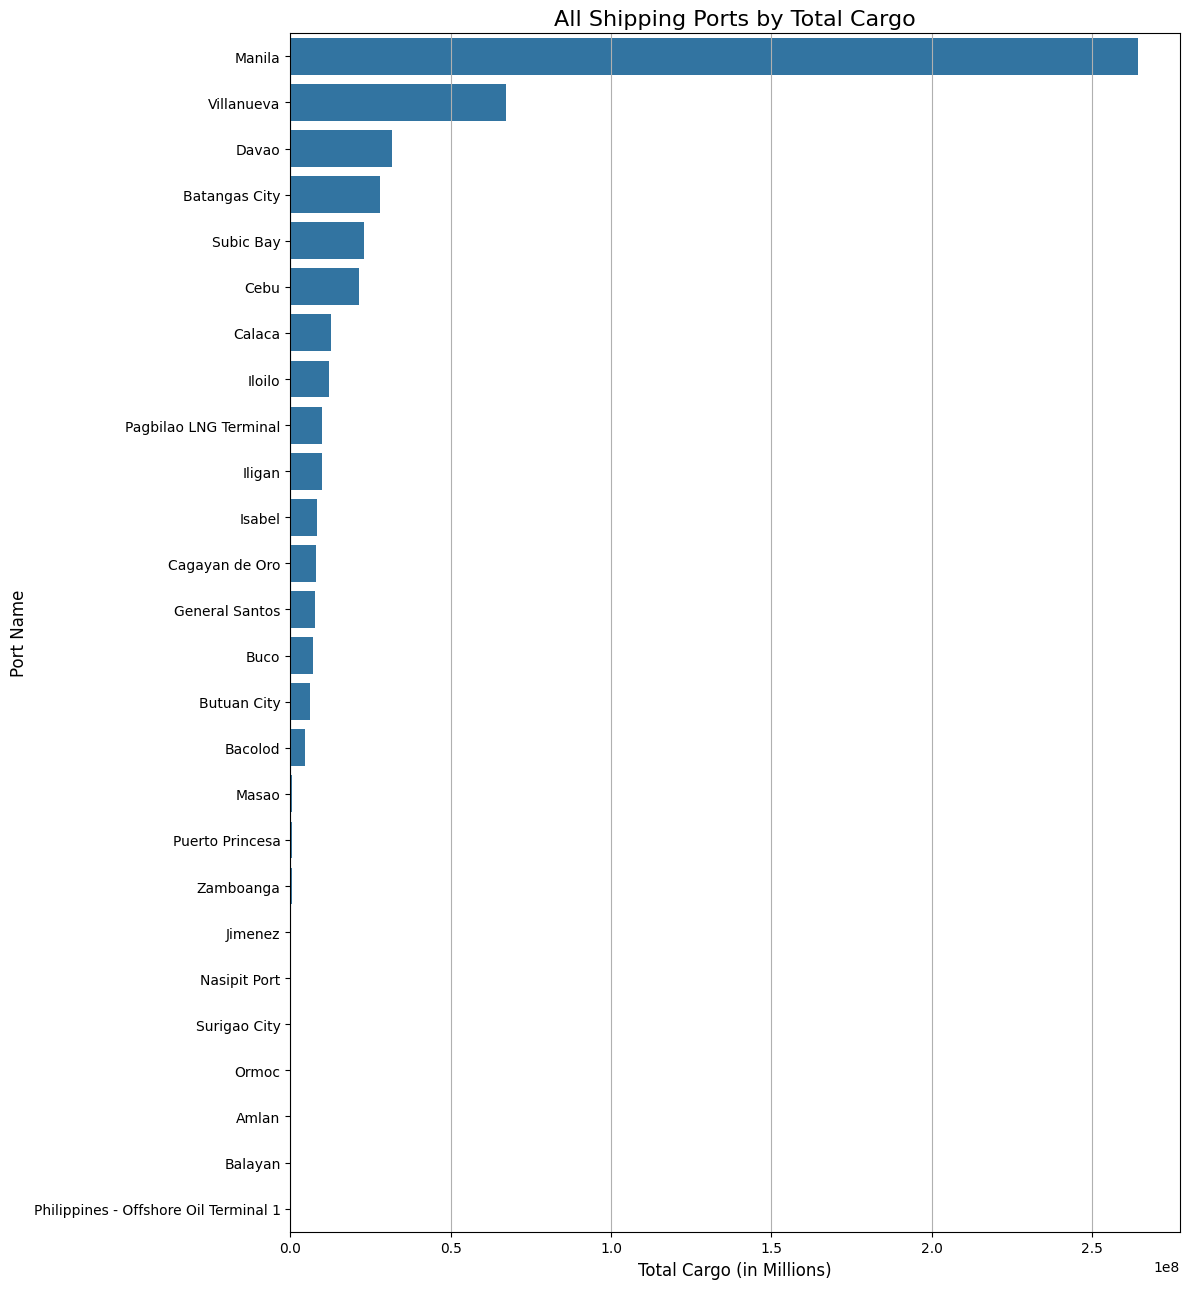

In [34]:
import seaborn as sns
# Calculate total cargo for each port
port_traffic = df.groupby('portname')[['import_cargo', 'export_cargo']].sum().reset_index()
port_traffic['total_cargo'] = port_traffic['import_cargo'] + port_traffic['export_cargo']

# Sort all ports by total cargo for better visualization
all_ports_traffic = port_traffic.sort_values(by='total_cargo', ascending=False)

fig_height = max(6, 26 * 0.5)

plt.figure(figsize=(12, fig_height))
sns.barplot(x = 'total_cargo', y = 'portname', data=all_ports_traffic)
plt.title('All Shipping Ports by Total Cargo', fontsize = 16)
plt.xlabel('Total Cargo (in Millions)', fontsize = 12)
plt.ylabel('Port Name', fontsize=12)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Nutshell Plot

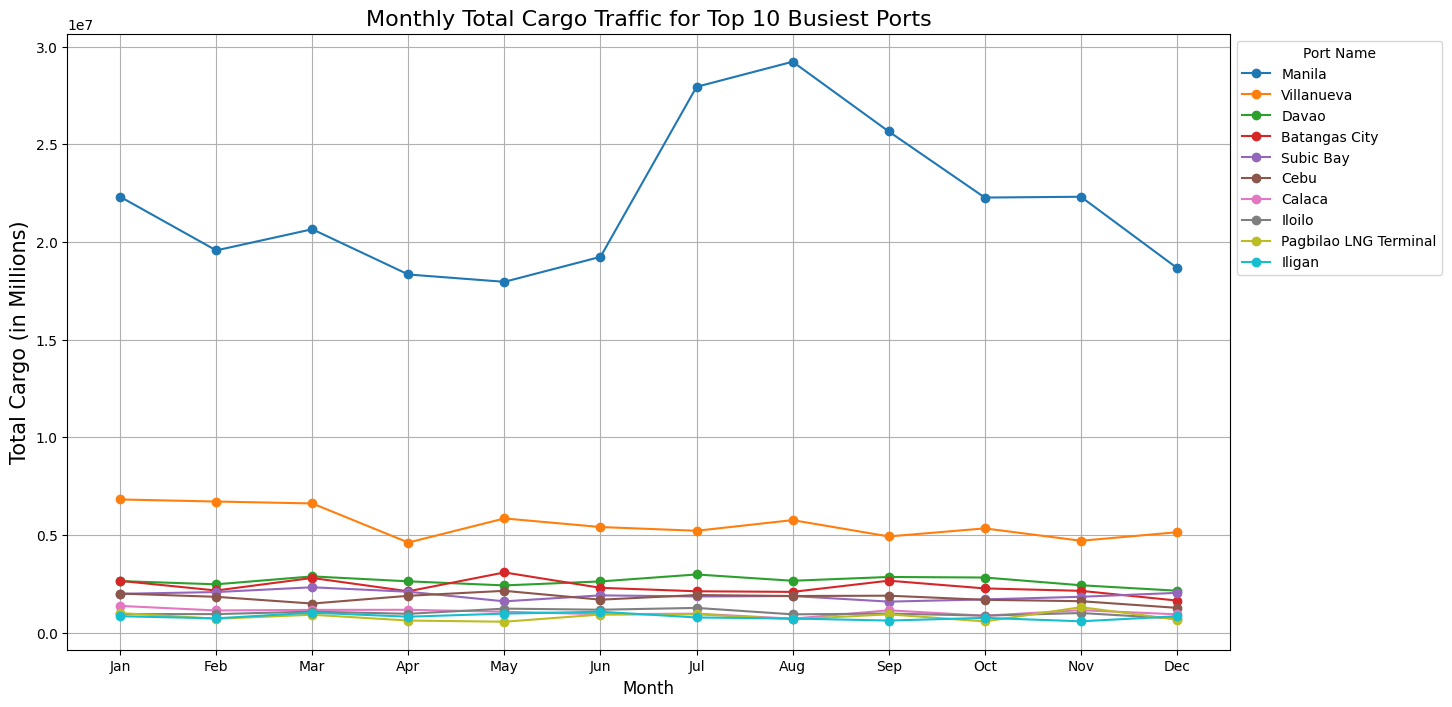

In [30]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# Calculate monthly total cargo for all individual ports
monthly_individual = df.groupby(['portname', 'month'])[['import_cargo', 'export_cargo']].sum().reset_index()
monthly_individual['total_cargo'] = monthly_individual['import_cargo'] + monthly_individual['export_cargo']

# Calculate total cargo per port to find the top 10
port_total_cargo = monthly_individual.groupby('portname')['total_cargo'].sum().reset_index()
top_10_port_names = port_total_cargo.nlargest(10, 'total_cargo')['portname'].tolist()
top_10_ports_monthly_traffic = monthly_individual[monthly_individual['portname'].isin(top_10_port_names)]

plt.figure(figsize=(15, 8))

# Plot the top 10 ports on a single graph
for port in top_10_port_names:
    port_data = top_10_ports_monthly_traffic[top_10_ports_monthly_traffic['portname'] == port]
    plt.plot(port_data['month'], port_data['total_cargo'], marker='o', label=port)

plt.title('Monthly Total Cargo Traffic for Top 10 Busiest Ports', fontsize=16)
plt.xlabel('Month', fontsize = 12)
plt.ylabel('Total Cargo (in Millions)', fontsize = 15)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Port Name', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)
plt.show()